# Introducción a la Ciencia de Datos: Tarea 1

Este notebook contiene el código de base para realizar la Tarea 1 del curso. Puede copiarlo en su propio repositorio y trabajar sobre el mismo.
Las **instrucciones para ejecutar el notebook** están en la [página inicial del repositorio](https://gitlab.fing.edu.uy/maestria-cdaa/intro-cd).

Se utiliza el lenguaje Python y la librería Pandas. Si no tiene ninguna familiaridad con la librería, se recomienda realizar algún tutorial introductorio (ver debajo).
También se espera que los alumnos sean proactivos a la hora de consultar las documentaciones de las librerías y del lenguaje, para entender el código provisto.
Además de los recursos provistos en la [página del curso](https://eva.fing.edu.uy/course/view.php?id=1378&section=1), los siguientes recursos le pueden resultar interesantes:
 - [Pandas getting started](https://pandas.pydata.org/docs/getting_started/index.html#getting-started) y [10 minutes to pandas](https://pandas.pydata.org/docs/user_guide/10min.html): Son parte de la documentación en la página oficial de Pandas.
 - [Kaggle Learn](https://www.kaggle.com/learn): Incluye tutoriales de Python y Pandas.


Si desea utilizar el lenguaje R y está dispuesto a no utilizar (o traducir) este código de base, también puede hacerlo.

En cualquier caso, **se espera que no sea necesario revisar el código para corregir la tarea**, ya que todos los resultados y análisis relevantes deberían estar en el **informe en formato PDF**.

## Cargar bibliotecas (dependencias)
Recuerde instalar los requerimientos (`requirements.txt`) en el mismo entorno donde está ejecutando este notebook (ver [README](https://github.com/DonBraulio/introCD)).

In [215]:
from time import time
from pathlib import Path
from datetime import datetime, timedelta
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx
from datasets import load_dataset

# Agregue aqui el resto de las librerias que necesite
# from ...
# import ...

In [216]:
#pd.set_option("display.max_colwidth", 120)
#sns.set_theme(style="whitegrid")

## Descarga del dataset
En esta tarea se utilizará una base de datos abierta que contiene artículos de noticias publicados en distintos medios de prensa, con la finalidad de realizar una clasificación de textos según el medio de prensa al que pertenecen. [Link](https://huggingface.co/datasets/rjac/all-the-news-2-1-Component-one?utm_source=chatgpt.com) \
\
Ejecute la siguiente celda para descargar los datos y cargarlos en un dataframe de pandas. La constante `DATA_PATH` determina la ubicación donde se almacenaran los datos. \
\
El dataset entero pesa ~8.3gb. Para evitar demoras en la descarga/procesamiento vamos a utilizar el parámetro `streaming=True` y hacer un muestreo aleatorio para descargar una porción de los datos lo más representativa posible.

In [217]:
ds = load_dataset("tomas-gr/all-the-news-2-1-Component-one-sampled", split="train",cache_dir="../data")
df = ds.to_pandas()

## Lectura de Datos

In [218]:
# Veamos las primeras filas del DataFrame
df.head()

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
0,1,1,2018-02-02,2018,2.0,2,None,BRIEF-Teva Says Fremanezumab Marketing Authorization Application Accepted By EMA,Feb 2 (Reuters) - Teva Pharmaceutical Industries Ltd : * EUROPEAN MEDICINES AGENCY (EMA) ACCEPTS FREMANEZUMAB MARKET...,https://www.reuters.com/article/brief-teva-says-fremanezumab-marketing-a/brief-teva-says-fremanezumab-marketing-auth...,Healthcare,Reuters
1,2,2,2018-05-01,2018,5.0,1,None,CMS' Verma says it’s time health care caught up to other industries,The head of the Centers for Medicare and Medicaid Services said Monday it's time that health care catches up with ot...,https://www.cnbc.com/2018/04/30/cms-verma-says-its-time-health-care-caught-up-to-other-industries.html,Health and Science,CNBC
2,3,3,2017-08-14,2017,8.0,14,Harper Neidig,Uber investor accuses Kalanick of 'undermining' search for his replacement | TheHill,"Benchmark, the venture capital firm that helped push Travis Kalanick out of Uber, told the company’s employees on Mo...",https://thehill.com/policy/technology/346520-uber-investors-accuse-travis-kalanick-of-undermining-search-for-his,None,The Hill
3,4,4,2017-04-03 00:00:00,2017,4.0,3,None,Chad Johnson Catches Uno Touchdown In Mexican Pro Football Debut (Video),VIVA OCHOCINCO!!!!! Chad Johnson made his triumphant return to pro football this weekend -- IN MEXICO -- and reeled ...,https://www.tmz.com/2017/04/03/chad-johnson-mexico-football-video/,None,TMZ
4,5,5,2018-12-27 19:20:08,2018,12.0,27,Aja Romano,"Hopepunk, explained: the storytelling trend that weaponizes optimism","Literary and artistic movements often arise spontaneously, out of specific moments — as a response to great cultural...",https://www.vox.com/2018/12/27/18137571/what-is-hopepunk-noblebright-grimdark,None,Vox


In [219]:
# Veamos información general del DataFrame
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30213 entries, 0 to 30212
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   idx          30213 non-null  int64 
 1   article_idx  30213 non-null  int64 
 2   date         30213 non-null  object
 3   year         30213 non-null  object
 4   month        30213 non-null  object
 5   day          30213 non-null  object
 6   author       18808 non-null  object
 7   title        30213 non-null  object
 8   article      29037 non-null  object
 9   url          30072 non-null  object
 10  section      19981 non-null  object
 11  publication  30072 non-null  object
dtypes: int64(2), object(10)
memory usage: 2.8+ MB


# Parte 1: Cargado y Limpieza de Datos

## A. Exploración de Datos
Analice el contenido del DataFrame. Reporte si existen datos faltantes en algún campo, o cualquier otro problema de calidad de datos que encuentre. \
En particular, analice la cantidad de artículos por medio de prensa, y a partir de este punto trabaje con los **cinco medios con mayor cantidad de artículos**.

In [220]:
# Análisis de valores nulos por columna
missing = pd.DataFrame({
    "nulos":      df.isna().sum(),
    "porcentaje": (df.isna().mean() * 100).round(1)
}).sort_values("nulos", ascending=False)

print(missing.to_string())


             nulos  porcentaje
author       11405        37.7
section      10232        33.9
article       1176         3.9
url            141         0.5
publication    141         0.5
idx              0         0.0
article_idx      0         0.0
date             0         0.0
year             0         0.0
month            0         0.0
day              0         0.0
title            0         0.0


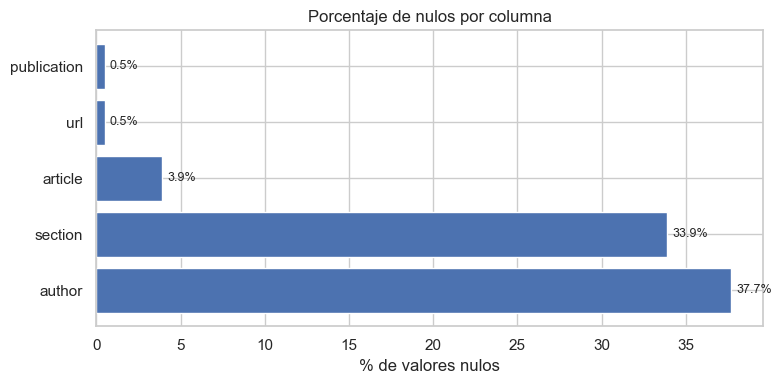

In [221]:
# Visualización: porcentaje de nulos por columna
cols_with_nulls = missing[missing["nulos"] > 0]

fig, ax = plt.subplots(figsize=(8, 4))
ax.barh(cols_with_nulls.index, cols_with_nulls["porcentaje"])
ax.set_xlabel("% de valores nulos")
ax.set_title("Porcentaje de nulos por columna")
for i, v in enumerate(cols_with_nulls["porcentaje"]):
    ax.text(v + 0.3, i, f"{v}%", va="center", fontsize=9)
plt.tight_layout()
plt.show()


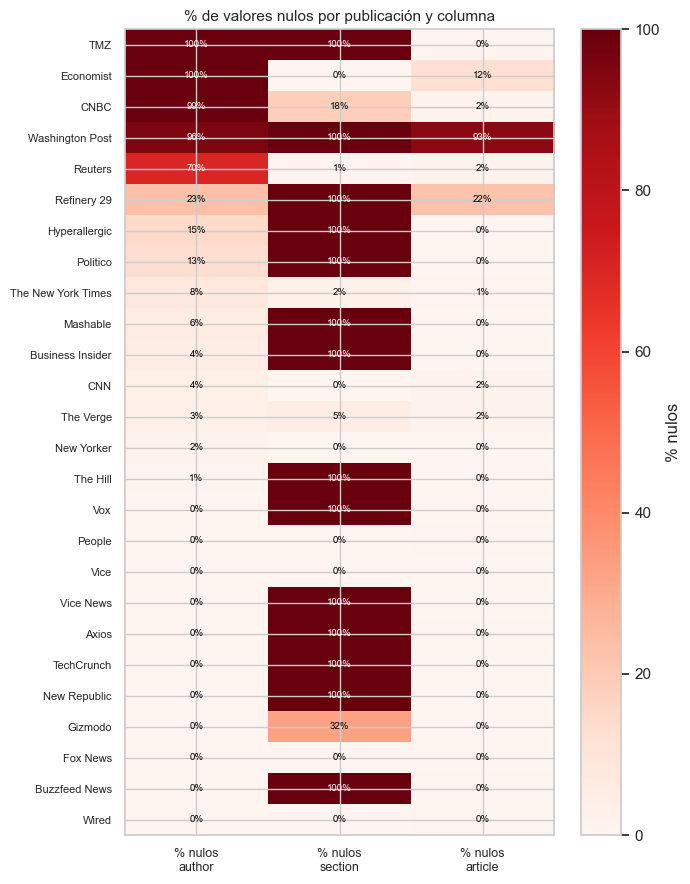

,% nulos author,% nulos section,% nulos article
publication,,,
TMZ,100.0,100.0,0.4
Economist,100.0,0.0,12.2
CNBC,99.1,18.5,1.7
Washington Post,95.7,99.8,92.9
Reuters,69.7,0.9,1.7
Refinery 29,23.3,100.0,22.4
Hyperallergic,14.6,100.0,0.0
Politico,12.9,100.0,0.2
The New York Times,8.3,2.4,1.1


In [222]:
# Nulos por publicación — todas las publicaciones con >= 50 artículos
# Permite detectar si los nulos se concentran en medios específicos

pub_counts = df["publication"].value_counts()
pubs_validas = pub_counts[pub_counts >= 50].index
sub_pubs = df[df["publication"].isin(pubs_validas)]

cols_key = ["author", "section", "article"]
null_by_pub = pd.DataFrame({
    col: sub_pubs.groupby("publication")[col]
              .apply(lambda x: round(x.isna().mean() * 100, 1))
    for col in cols_key
}).sort_values("author", ascending=False)

null_by_pub.columns = [f"% nulos {c}" for c in cols_key]

# Heatmap
fig, ax = plt.subplots(figsize=(7, 9))
im = ax.imshow(null_by_pub.values, aspect="auto", cmap="Reds", vmin=0, vmax=100)
plt.colorbar(im, ax=ax, label="% nulos")
ax.set_xticks(range(len(cols_key)))
ax.set_xticklabels([f"% nulos\n{c}" for c in cols_key], fontsize=9)
ax.set_yticks(range(len(null_by_pub)))
ax.set_yticklabels(null_by_pub.index, fontsize=8)
for i in range(len(null_by_pub)):
    for j in range(len(cols_key)):
        val = null_by_pub.values[i, j]
        color = "white" if val > 55 else "black"
        ax.text(j, i, f"{val:.0f}%", ha="center", va="center", fontsize=7, color=color)
ax.set_title("% de valores nulos por publicación y columna", fontsize=11)
plt.tight_layout()
plt.show()

null_by_pub


**Conclusiones del análisis de nulos:**

- **`author` (37.7% global)**: los nulos se concentran en medios que publican notas
  sin firma: TMZ y Economist (100%), CNBC (99%), Washington Post (96%), Reuters (70%).
  La columna no será útil para el análisis de texto.

- **`section` (33.9% global)**: la mayoría de los medios digitales no la completan
  (The Hill, Vox, Politico, Axios, etc. tienen 100% nulos). Solo Reuters, CNN,
  The New York Times y People la utilizan de forma consistente.

- **`article` (3.9% global)**: el problema más grave es **Washington Post**, con el 92.9%
  de sus artículos sin contenido — razón por la que no aparece en el top 5 pese a tener
  muchas filas. Refinery 29 también tiene un 22.4% sin contenido. Estos artículos
  se eliminan en el paso de limpieza con `dropna(subset=['article'])`.

- **`url` y `publication` (0.5%)**: 141 filas sin publicación identificada, distribuidas
  uniformemente. Se eliminan al filtrar por publicación.

- **`date`, `title`, `idx`**: sin valores nulos — columnas confiables en todo el dataset.

In [223]:
# Calidad de la columna 'date': formatos mixtos
# Se observan tres variantes en la misma columna:
#   - Solo fecha:          '2018-02-02'
#   - Con timestamp real:  '2018-12-27 19:20:08'
#   - Con timestamp vacío: '2017-04-03 00:00:00'  (hora no disponible)

has_timestamp = df["date"].str.contains(r"\d{2}:\d{2}:\d{2}", na=False)
midnight      = df["date"].str.endswith("00:00:00", na=False)
date_only     = ~has_timestamp

print(f"Total de filas:                        {len(df)}")
print(f"Solo fecha (ej: 2018-02-02):           {date_only.sum():>6}  ({date_only.mean()*100:.1f}%)")
print(f"Con timestamp real (ej: 19:20:08):     {(has_timestamp & ~midnight).sum():>6}  ({(has_timestamp & ~midnight).mean()*100:.1f}%)")
print(f"Con timestamp vacío (00:00:00):        {midnight.sum():>6}  ({midnight.mean()*100:.1f}%)")
print()
# Con pandas >= 2.0, pd.to_datetime requiere format='mixed' para columnas con formatos distintos.
# Sin ese parámetro, infiere el formato solo de las primeras filas y falla en el resto.
fallos_sin_mixed = pd.to_datetime(df["date"], errors="coerce").isna().sum()
fallos_con_mixed = pd.to_datetime(df["date"], errors="coerce", format="mixed").isna().sum()
print(f"Fechas no parseadas sin format='mixed': {fallos_sin_mixed}")
print(f"Fechas no parseadas con format='mixed': {fallos_con_mixed}")
print("→ Siempre usar format='mixed' al parsear esta columna.")

Total de filas:                        30213
Solo fecha (ej: 2018-02-02):            10799  (35.7%)
Con timestamp real (ej: 19:20:08):       7738  (25.6%)
Con timestamp vacío (00:00:00):         11676  (38.6%)

Fechas no parseadas sin format='mixed': 19414
Fechas no parseadas con format='mixed': 0
→ Siempre usar format='mixed' al parsear esta columna.


In [224]:
# Duplicados

df.duplicated().sum()

0

In [225]:
# Duplicados (por titulo, fecha y publicación)
dup_count = df.duplicated(subset=["title", "date", "publication"]).sum()
dup_count

174

In [226]:
# Inspección de duplicados reales (dentro del mismo medio)
df[df.duplicated(subset=["title", "date", "publication"], keep=False)] \
    .sort_values(["publication", "title", "date"]) \
    .head(10)

,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
231,232,232,2018-04-05,2018,4.0,5,None,Not Found,None,https://www.cnbc.com/2019/02/13/reuters-america-australia-flooding-to-disrupt-lead-zinc-concentrate-rail-shipments.html,None,CNBC
1073,1074,1074,2018-04-05,2018,4.0,5,None,Not Found,None,https://www.cnbc.com/2019/02/12/reuters-america-update-1-basf-to-launch-construction-chemicals-unit-sale-in-spring--...,None,CNBC
5072,5073,5073,2018-04-05,2018,4.0,5,None,Not Found,None,https://www.cnbc.com/2019/02/12/reuters-america-grains-soybeans-up-as-news-of-u-s-china-trade-talks-awaited.html,None,CNBC
10275,10276,10276,2018-04-05,2018,4.0,5,None,Not Found,None,https://www.cnbc.com/2019/02/13/reuters-america-update-6-wary-of-shutdown-trump-edges-toward-support-for-funding-dea...,None,CNBC
20929,20930,20930,2018-04-05,2018,4.0,5,None,Not Found,None,https://www.cnbc.com/2019/02/10/reuters-america-update-3-cdu-at-phillips-66-wood-river-refinery-shut-by-fire-source....,None,CNBC
21345,21346,21346,2018-04-05,2018,4.0,5,None,Not Found,None,https://www.cnbc.com/2019/02/11/reuters-america-update-1-feds-bowman-says-she-is-comfortable-with-policy-stance.html,None,CNBC
25186,25187,25187,2018-04-05,2018,4.0,5,None,Not Found,None,https://www.cnbc.com/2019/02/11/reuters-america-update-9-u-s-lawmakers-reach-tentative-deal-to-avoid-government-shut...,None,CNBC
26606,26607,26607,2018-04-05,2018,4.0,5,None,Not Found,None,https://www.cnbc.com/2019/02/12/reuters-america-ukraine-to-issue-debt-under-world-bank-guarantee-by-end-february.html,None,CNBC
28531,28532,28532,2018-04-05,2018,4.0,5,None,Not Found,None,https://www.cnbc.com/2018/11/15/facebook-board-says-it-tried-to-push-zuckerberg-and-sandberg-to-move-faster-on-russi...,None,CNBC
4301,4302,4302,2018-04-05 00:00:00,2018,4.0,5,None,Not Found,None,https://www.cnbc.com/2020/01/27/reuters-america-u-s-stock-rally-faces-major-test-as-china-virus-spreads.html,None,CNBC


In [227]:
# Duplicados (por title + article + date)

dup_count = df.duplicated(subset=[ "date", "year", "month", "day", "author", "title", "article", "url", "section", "publication"]).sum()
dup_count

140

In [228]:
# Inspección de duplicados
df[df.duplicated(subset=[ "date", "year", "month", "day", "author", "title", "article", "url", "section", "publication"], keep=False)] \
    .sort_values(["date", "year", "month", "day", "author", "title", "article", "url", "section", "publication"]) \
    .head()


,idx,article_idx,date,year,month,day,author,title,article,url,section,publication
660,661,661,2019-03-08 00:00:00,2019,3.0,8,None,Book review of,None,None,None,None
916,917,917,2019-03-08 00:00:00,2019,3.0,8,None,Book review of,None,None,None,None
927,928,928,2019-03-08 00:00:00,2019,3.0,8,None,Book review of,None,None,None,None
1086,1087,1087,2019-03-08 00:00:00,2019,3.0,8,None,Book review of,None,None,None,None
1135,1136,1136,2019-03-08 00:00:00,2019,3.0,8,None,Book review of,None,None,None,None


In [229]:
# Duplicados SOLO por title + date (capaz sirve para despues, para decir que hay publicaciones diferentes para mismo articulo)
dup_loose = df.duplicated(subset=["title", "date"]).sum()

dup_loose, dup_count

(177, 140)

**Resumen de decisiones de limpieza:**

| Problema | Filas afectadas | Decisión |
|---|---|---|
| Duplicados por título+día+publicación | ~178 | Eliminar con `drop_duplicates` usando fecha parseada |
| Artículos con título 'Not Found' | 23 (CNBC) | Eliminar — errores de scraping sin contenido |
| Artículos sin cuerpo de texto (`article` vacío) | 1.176 | Eliminar — no son analizables |

La deduplicación se realiza sobre la **fecha parseada** (no el string original) para evitar
que `'2018-10-15'` y `'2018-10-15 00:00:00'` se consideren días distintos.

In [230]:
# Parsear fecha antes de deduplicar para evitar que '2018-10-15' y '2018-10-15 00:00:00'
# se traten como fechas distintas en la comparación de strings
df["date_parsed"] = pd.to_datetime(df["date"], errors="coerce", format="mixed")
df["date_day"]    = df["date_parsed"].dt.date  # solo la parte de fecha (sin hora)

# Eliminar duplicados reales: mismo título, mismo día y misma publicación
df_clean = df.drop_duplicates(subset=["title", "date_day", "publication"]).copy()

# Eliminar artículos sin contenido útil:
# - Título 'Not Found': errores de scraping (23 filas, todas de CNBC)
# - article vacío (NaN): 1.176 filas sin cuerpo de texto
df_clean = df_clean[df_clean["title"] != "Not Found"]
df_clean = df_clean.dropna(subset=["article"])

print(f"Filas tras limpieza: {len(df_clean)}  (originales: {len(df)})")
print(f"Eliminados: {len(df) - len(df_clean)}")
df_clean.shape

Filas tras limpieza: 29025  (originales: 30213)
Eliminados: 1188


(29025, 14)

In [231]:
# Corrección de tipos: 'month' aparece como float (ej: 2.0) en lugar de entero
# Causa: Pandas infiere float cuando una columna numérica tiene valores nulos,
# ya que el tipo int clásico no admite NaN. Con 'Int64' (nullable integer) se resuelve.

for col in ["year", "month", "day"]:
    df_clean[col] = pd.to_numeric(df_clean[col], errors="coerce").astype("Int64")

print("Tipos de datos corregidos:")
print(df_clean[["year", "month", "day"]].dtypes)
print("\nEjemplo (primeras 3 filas):")
df_clean[["year", "month", "day"]].head(3)

Tipos de datos corregidos:
year     Int64
month    Int64
day      Int64
dtype: object

Ejemplo (primeras 3 filas):


,year,month,day
0,2018,2,2
1,2018,5,1
2,2017,8,14


In [232]:
# Cantidad de artículos por medio de prensa (dataset sin limpiar y dataset limpio)
print("Dataset original:")
print(df["publication"].value_counts().head(10).to_string())
print()
print("Dataset limpio (df_clean):")
print(df_clean["publication"].value_counts().head(10).to_string())


Dataset original:
publication
Reuters               9431
The New York Times    2840
CNBC                  2623
The Hill              2349
People                1528
CNN                   1446
Refinery 29           1236
Vice                  1154
Mashable              1045
Business Insider       660

Dataset limpio (df_clean):
publication
Reuters               9266
The New York Times    2805
CNBC                  2578
The Hill              2349
People                1522
CNN                   1418
Vice                  1153
Mashable              1045
Refinery 29            959
Business Insider       660


In [233]:
# Trabajar sobre dataset limpio
df_pub = df_clean.dropna(subset=["publication"])

pub_counts = (
    df_pub["publication"]
    .value_counts()
    .sort_values(ascending=False)
)

pub_counts.head()

publication
Reuters               9266
The New York Times    2805
CNBC                  2578
The Hill              2349
People                1522
Name: count, dtype: int64

In [234]:
top_5_publications = pub_counts.head(5).index.tolist()
top_5_publications

['Reuters', 'The New York Times', 'CNBC', 'The Hill', 'People']

In [235]:
df_top_5 = df_pub[df_pub["publication"].isin(top_5_publications)].copy()

df_top_5["publication"].value_counts()

publication
Reuters               9266
The New York Times    2805
CNBC                  2578
The Hill              2349
People                1522
Name: count, dtype: int64

## B. Visualización temporal
Genere una gráfica que permita visualizar los artículos de los cinco medios a lo largo del tiempo, con alguna escala temporal adecuada. \
Comente si se identifican momentos de mayor actividad o patrones temporales en la cobertura.

In [236]:
# TODO: Visualización de los artículos de cada medio a lo largo del tiempo
# Preste especial atención al formato de la columna 'date', ya que puede contener diferentes formatos de fecha.


In [237]:
df[df["publication"] == "The New York Times"]["date"].head(10)

8     2019-05-23 09:30:04
9     2018-12-30 08:33:24
25    2018-03-07 01:00:43
28    2019-10-01 09:17:03
29    2020-02-10 04:35:00
33    2018-04-24 14:21:06
34    2016-07-08 10:02:11
35    2019-12-09 03:00:09
43    2019-04-15 10:01:52
44    2019-09-06 15:25:53
Name: date, dtype: object

In [238]:
# Verificar que todas las fechas parsean correctamente
# Se usa format='mixed' para manejar los distintos formatos presentes en la columna
parsed = pd.to_datetime(df_top_5["date"], errors="coerce", format="mixed")

df_top_5.loc[parsed.isna(), "publication"].value_counts()

Series([], Name: count, dtype: int64)

In [239]:
# Convertir fecha al tipo datetime
# format='mixed' es necesario porque la columna mezcla '2018-02-02' y '2018-12-27 19:20:08'
df_top_5["date"] = pd.to_datetime(df_top_5["date"], errors="coerce", format="mixed")

# Eliminar fechas inválidas (si las hubiera)
df_top_5 = df_top_5.dropna(subset=["date"]).copy()

# Crear columna año-mes para la visualización temporal
df_top_5["year_month"] = df_top_5["date"].dt.to_period("M")


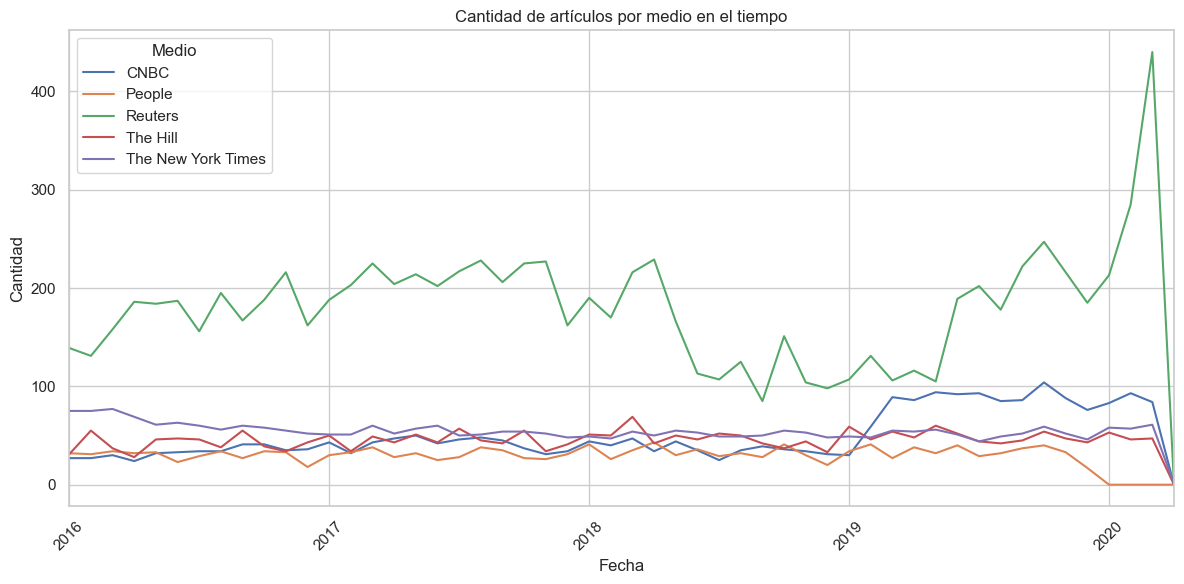

In [240]:
time_series = (
    df_top_5
    .groupby(["year_month", "publication"])
    .size()
    .unstack(fill_value=0)
)

# Period index must be converted to Timestamp for matplotlib
time_series.index = time_series.index.to_timestamp()

plt.figure(figsize=(12,6))
time_series.plot(ax=plt.gca())

plt.title("Cantidad de artículos por medio en el tiempo")
plt.xlabel("Fecha")
plt.ylabel("Cantidad")
plt.xticks(rotation=45)
plt.legend(title="Medio")

plt.tight_layout()
plt.show()


## C. Limpieza de texto y conteo de palabras
Se provee la función `clean_text(...)` que realiza parte de la normalización del texto. \
**Complete la función** agregando signos de puntuación faltantes y cualquier otra normalización que considere oportuna. \
Compruebe el resultado observando el contenido del DataFrame procesado. Comente todas las transformaciones que haya agregado y justifique.

In [241]:
def clean_text(df, col_title, col_article):
    """
    Combina título y cuerpo del artículo, y normaliza el texto:
    - Concatena title + article (separados por espacio)
    - Elimina el dateline inicial hasta el primer salto de línea (ej: 'Feb 2 (Reuters) -\n')
    - Convierte a minúsculas
    - Elimina URLs (http://... o www....)
    - Elimina toda la puntuación con regex (más robusto que reemplazar caracter a caracter)
    - Colapsa espacios múltiples y elimina espacios al inicio/final
    """
    # Combinar título y artículo (rellenar NaN con cadena vacía)
    result = df[col_title].fillna("") + " " + df[col_article].fillna("")

    # Eliminar dateline inicial hasta el primer salto de línea
    result = result.str.replace(r"^[^\n]*\n", "", regex=True)

    # Convertir a minúsculas
    result = result.str.lower()

    # Eliminar URLs
    result = result.str.replace(r"https?://\S+|www\.\S+", " ", regex=True)

    # Eliminar puntuación y caracteres especiales (conservar solo letras, números y espacios)
    result = result.str.replace(r"[^a-z0-9\s]", " ", regex=True)

    # Colapsar espacios múltiples y limpiar bordes
    result = result.str.replace(r"\s+", " ", regex=True).str.strip()

    return result


In [242]:
# Aplicar clean_text combinando título y cuerpo del artículo
# Decisión (ver 1D): se usa la combinación de ambos campos para
# capturar tanto el tema central (título) como el contenido detallado (artículo)

df_top_5["CleanText"] = clean_text(df_top_5, "title", "article")

df_top_5[["title", "article", "CleanText"]].head()

,title,article,CleanText
0,BRIEF-Teva Says Fremanezumab Marketing Authorization Application Accepted By EMA,Feb 2 (Reuters) - Teva Pharmaceutical Industries Ltd : * EUROPEAN MEDICINES AGENCY (EMA) ACCEPTS FREMANEZUMAB MARKET...,brief teva says fremanezumab marketing authorization application accepted by ema feb 2 reuters teva pharmaceutical i...
1,CMS' Verma says it’s time health care caught up to other industries,The head of the Centers for Medicare and Medicaid Services said Monday it's time that health care catches up with ot...,cms verma says it s time health care caught up to other industries the head of the centers for medicare and medicaid...
2,Uber investor accuses Kalanick of 'undermining' search for his replacement | TheHill,"Benchmark, the venture capital firm that helped push Travis Kalanick out of Uber, told the company’s employees on Mo...",uber investor accuses kalanick of undermining search for his replacement thehill benchmark the venture capital firm ...
5,"UPDATE 2-Magellan Health bows to Starboard pressure, names four to board","(Updates with new first paragraph, adds background) March 29 (Reuters) - Magellan Health Inc said on Friday it reach...",update 2 magellan health bows to starboard pressure names four to board updates with new first paragraph adds backgr...
6,Bank of Montreal's quarterly earnings beat market forecasts,"TORONTO, Dec 4 (Reuters) - Bank of Montreal on Tuesday reported a 19 percent increase in fourth quarter earnings, be...",bank of montreal s quarterly earnings beat market forecasts toronto dec 4 reuters bank of montreal on tuesday report...


## D. Elección de campos de texto
Discuta si conviene trabajar con:
- sólo el cuerpo del artículo,
- sólo el título,
- o una combinación de ambos.

Justifique brevemente su decisión.

Se evaluaron tres opciones: utilizar sólo el cuerpo del artículo, sólo el título, o una combinación de ambos.

El cuerpo del artículo aporta mayor cantidad de información y contexto, pero introduce más ruido. El título, en cambio, resume el tema principal, aunque puede resultar insuficiente o ambiguo por su brevedad.

Por este motivo, se opta por utilizar una **combinación del título y el cuerpo del artículo**, ya que permite capturar tanto el tema central como el contenido detallado, logrando una representación más completa y equilibrada del texto.

## E. Pistas que identifican al medio de prensa
Analice si en el texto aparecen pistas que identifiquen de manera directa al medio de prensa (nombres del medio, URLs, firmas, nombres de secciones, plantillas repetidas, etc.). \
En caso de encontrarlas, comente si considera conveniente eliminarlas o reducir su impacto, y justifique su decisión.

In [243]:
# Análisis de pistas identificadoras del medio en el texto
# Se buscan tres tipos de señales: presencia de URLs, auto-mención del medio y
# patrones de los otros cuatro medios dentro del CleanText de cada publicación.

In [244]:
df_top_5["has_url"] = df_top_5["article"].str.contains("http|www", na=False)

df_top_5.groupby("publication")["has_url"].mean()

publication
CNBC                  0.036850
People                0.043364
Reuters               0.011440
The Hill              0.096211
The New York Times    0.002852
Name: has_url, dtype: float64

In [245]:
# auto-menciones
# porcentaje de articulos con auto-mencion por medio

def mentions_media(row):
    if pd.isna(row["CleanText"]) or pd.isna(row["publication"]):
        return False
    return row["publication"].lower() in row["CleanText"]

df_top_5["mentions_media"] = df_top_5.apply(mentions_media, axis=1)

df_top_5.groupby("publication")["mentions_media"].mean()

publication
CNBC                  0.351435
People                0.683968
Reuters               0.901360
The Hill              0.994040
The New York Times    0.171836
Name: mentions_media, dtype: float64

In [246]:
# mencion de medio de prensa en todos los articulos

patterns = ["reuters", "cnbc", "the hill", "new york times", "people"]

for p in patterns:
    print(p, df_top_5["CleanText"].str.contains(p, na=False).mean())

reuters 0.5017818574514039
cnbc 0.052159827213822896
the hill 0.12915766738660908
new york times 0.044654427645788336
people 0.3206803455723542


1. **Reuters es la fuente dominante del ecosistema**

Reuters aparece mencionado en el 50% de todos los artículos — esto tiene sentido porque :contentReference[oaicite:0]{index=0} es una agencia de noticias (*wire service*). Muchos artículos de otros medios citan "According to Reuters..." o están directamente basados en despachos de Reuters. Además, sus propios artículos casi siempre incluyen su nombre (90% auto-mención), típicamente como *byline* o atribución.

2. **"people" no es una señal confiable**

El 32% de los artículos contienen "people", pero eso probablemente corresponde a la palabra común en inglés, no a referencias a :contentReference[oaicite:1]{index=1}. El patrón es demasiado genérico para ser útil como indicador. Habría que usar "people magazine" o buscar con mayúscula en texto sin limpiar.

3. **The Hill tiene auto-mención casi universal (99%)**

Sugiere que el nombre aparece en una plantilla o *boilerplate* de cada artículo (pie de página, header, byline). No significa que los periodistas escriban "The Hill" en cada nota — es un artefacto del formato.

4. **NYT es el más "limpio" en ambas métricas**

:contentReference[oaicite:2]{index=2} tiene baja auto-mención (17%), casi sin URLs (0.3%), y poca mención por otros medios (4.5%). Refleja un estilo más formal y tradicional, con menos artefactos de formato digital.

5. **Las URLs correlacionan con el estilo digital**

:contentReference[oaicite:3]{index=3} (9.6%) y :contentReference[oaicite:4]{index=4} (4.3%) son medios más digitales/web-native. Reuters y NYT son outlets de prensa tradicional que no suelen embebder links en el cuerpo del artículo.

In [247]:
df_top_5["article"].sample(5).values

array(["BARCELONA (Thomson Reuters Foundation) - From fuel made out of waste in Uganda to healthy nut snacks in Nicaragua, small firms in developing countries will get direct links to international investors under a new scheme to help them expand and bring extra income to poor communities. Five British charities have created a syndicate through which investors can back hand-picked businesses, using a model similar to that of the “Dragon’s Den” TV series in which entrepreneurs pitch ideas to prospective funders. Around 70 percent of small and medium-sized businesses in developing countries cannot access capital, according to Christian Aid, which co-founded the scheme called “Access To Capital For Rural Enterprises” (ACRE), launched on Thursday. Investors, both local and global, often see deals with smaller companies as too risky or expensive, said Joanna Heywood, who leads the ACRE program for Christian Aid. “There were a lot of enterprises we came across that were buying, or wanted to 

## F. Restricción por sección o período temporal
Evalúe si conviene restringir el análisis a artículos de una misma sección temática o de un período temporal acotado, con el objetivo de reducir el efecto del tema sobre una futura tarea de clasificación por medio. \
No es necesario implementar esta restricción, pero sí discutir sus posibles ventajas y desventajas.

Se evalúa la posibilidad de restringir el análisis a una misma sección temática o a un período temporal acotado con el fin de reducir el sesgo por tema en una futura tarea de clasificación por medio.

**Ventajas:**
- Permite comparar medios bajo condiciones más homogéneas (mismo tema o contexto temporal).
- Reduce el riesgo de que el modelo aprenda a distinguir temas (por ejemplo, política vs. economía) en lugar del estilo o características propias del medio.
- Facilita una interpretación más clara de los resultados.

**Desventajas:**
- Reduce significativamente la cantidad de datos disponibles.
- Puede eliminar variabilidad relevante del comportamiento real de los medios.
- Limita la generalización del modelo a otros temas o períodos.

En conclusión, restringir por sección o período puede ser útil para aislar el efecto del medio y construir un análisis más controlado, aunque implica un trade-off con la cantidad y diversidad de datos.

# Parte 2: Conteo de Palabras y Visualizaciones

## A. Palabras más frecuentes por medio
Realice una visualización que permita comparar las palabras más frecuentes de cada uno de los cinco medios de prensa. \
Sin necesidad de implementarlo, proponga ideas para modificar esta visualización con el fin de encontrar diferencias entre secciones temáticas, fechas, o tipos de noticias.

In [248]:
from collections import Counter

def get_top_words(text_series, n=10):
    words = " ".join(text_series.dropna()).split()
    return Counter(words).most_common(n)

In [249]:
top_words_per_pub = {}

for pub in top_5_publications:
    subset = df_top_5[df_top_5["publication"] == pub]
    top_words_per_pub[pub] = get_top_words(subset["CleanText"], n=10)

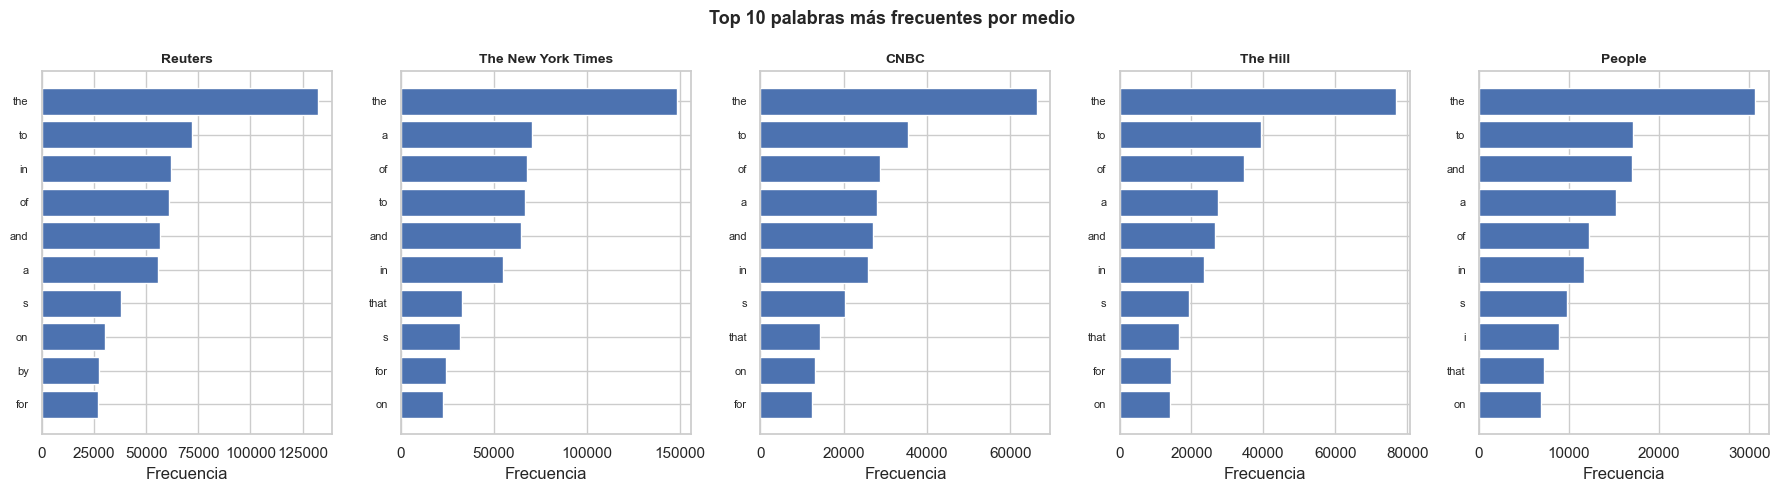

Observación: las palabras dominantes son artículos, preposiciones y verbos comunes
(stopwords). Esto dificulta encontrar diferencias entre medios con este enfoque.
Ver 2B para una discusión sobre cómo resolver esto.


In [250]:
# Visualización comparativa: top palabras por medio en un solo gráfico
# Nota: las palabras más frecuentes suelen ser stopwords (the, a, of, said...)
# Esto es esperable en cualquier corpus de texto en inglés y se discute en 2B.

n_words = 10
n_pubs  = len(top_5_publications)

fig, axes = plt.subplots(1, n_pubs, figsize=(18, 5), sharey=False)

for ax, pub in zip(axes, top_5_publications):
    words_df = pd.DataFrame(top_words_per_pub[pub], columns=["word", "count"])
    ax.barh(words_df["word"][::-1], words_df["count"][::-1])
    ax.set_title(pub, fontsize=10, fontweight="bold")
    ax.set_xlabel("Frecuencia")
    ax.tick_params(axis="y", labelsize=8)

fig.suptitle("Top 10 palabras más frecuentes por medio", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Observación: las palabras dominantes son artículos, preposiciones y verbos comunes")
print("(stopwords). Esto dificulta encontrar diferencias entre medios con este enfoque.")
print("Ver 2B para una discusión sobre cómo resolver esto.")

**Ideas para extender la visualización de palabras frecuentes**

- **Por sección temática**: filtrar `df_top_5` por `section` antes de calcular
  las frecuencias. Comparar las top palabras de cada medio *dentro de la misma sección*
  (ej. `"politics"`) reduciría el efecto del tema y revelaría diferencias de estilo.

- **Por período temporal**: agrupar por año o trimestre y calcular las palabras más
  frecuentes por medio en cada período. Permitiría detectar si ciertos eventos
  (elecciones, crisis) generaron vocabulario diferencial entre medios.

- **Eliminando stopwords**: aplicar una lista de stopwords en inglés
  (ej. con `nltk.corpus.stopwords`) antes de contar. Esto haría emerger palabras
  temáticamente relevantes y distintas entre medios.

- **TF-IDF en lugar de frecuencia cruda**: las palabras con alto TF-IDF son
  frecuentes en un medio pero raras en los otros, lo que identifica vocabulario
  verdaderamente distintivo de cada publicación.

## B. Medios con mayor cantidad de palabras
Corra el código que permite encontrar los medios con mayor cantidad de palabras. \
En caso de encontrar algún problema luego de realizar la visualización, comente a qué se debe y proponga formas de resolverlo.

In [251]:
# Medios con mayor cantidad total de palabras

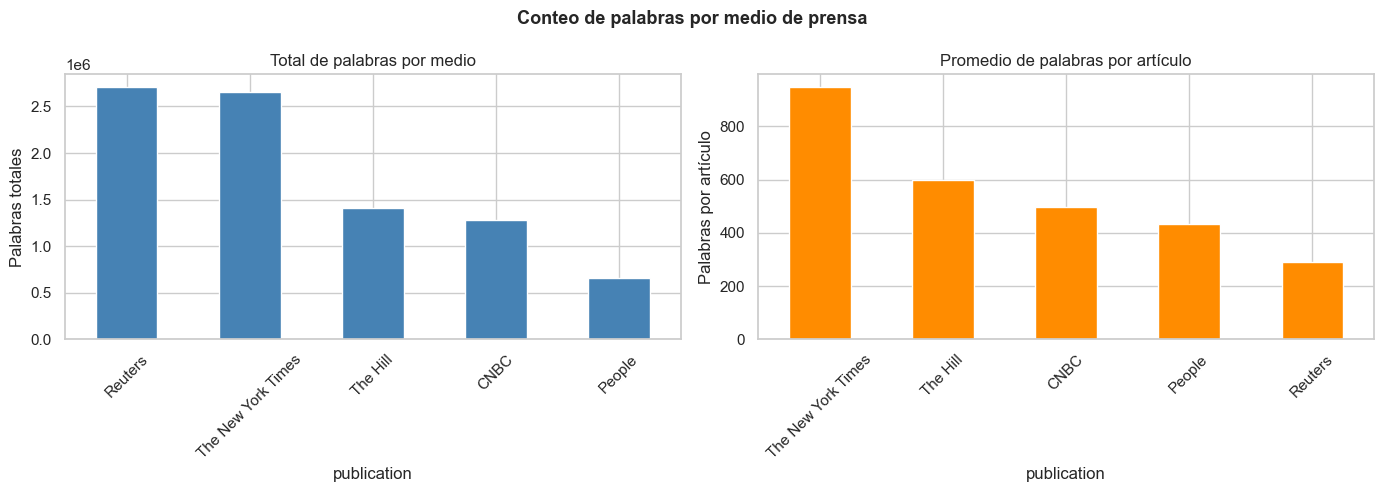

In [252]:
df_top_5["word_count"] = df_top_5["CleanText"].str.split().str.len()

total_words = (
    df_top_5.groupby("publication")["word_count"]
    .sum().sort_values(ascending=False)
)
avg_words = (
    df_top_5.groupby("publication")["word_count"]
    .mean().sort_values(ascending=False)
)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

total_words.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("Total de palabras por medio")
axes[0].set_ylabel("Palabras totales")
axes[0].tick_params(axis="x", rotation=45)

avg_words.plot(kind="bar", ax=axes[1], color="darkorange")
axes[1].set_title("Promedio de palabras por artículo")
axes[1].set_ylabel("Palabras por artículo")
axes[1].tick_params(axis="x", rotation=45)

fig.suptitle("Conteo de palabras por medio de prensa", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()


**Problema observado en 2B**

El ranking por cantidad total de palabras refleja principalmente el **volumen de artículos**
de cada medio, no su estilo de escritura. Reuters tiene ~9.400 artículos frente a
~1.500-2.800 del resto, por lo que encabeza el conteo aunque sus artículos sean más cortos.

**Formas de resolver esto:**

1. **Promedio de palabras por artículo** (`word_count.mean()` en lugar de `.sum()`): mide
   la extensión típica de los artículos de cada medio, independientemente del volumen.

2. **Eliminar stopwords antes de contar**: las palabras funcionales (`the`, `a`, `of`...)
   dominan el conteo total y no aportan diferencias entre medios.

3. **Normalizar por cantidad de artículos**: expresar el conteo como palabras por artículo
   hace comparables medios con distinto volumen de publicación.

## C. Matriz de menciones entre medios
Construya una matriz de 5×5, donde cada fila y columna corresponden a un medio de prensa, y la entrada (i,j) contiene la cantidad de veces que el medio *i* menciona al medio *j*. \
\
**Opcional:** genere un grafo dirigido con esa matriz de adyacencia para visualizar las menciones. Puede ser útil la biblioteca `networkx`.

In [253]:
# Patrones de búsqueda para cada medio
# Nota: se usa el nombre más distintivo de cada publicación.
# 'people' es una palabra común en inglés, por lo que su columna incluirá
# falsos positivos (usos del sustantivo 'people', no referencias a la revista).

media_patterns = {
    "Reuters":            "reuters",
    "The New York Times": "new york times",
    "CNBC":               "cnbc",
    "The Hill":           "the hill",
    "People":             "people",
}

mentions_matrix = pd.DataFrame(0, index=top_5_publications, columns=top_5_publications)

for i in top_5_publications:
    subset = df_top_5[df_top_5["publication"] == i]["CleanText"]
    for j in top_5_publications:
        pattern = media_patterns[j]
        mentions_matrix.loc[i, j] = subset.str.contains(pattern, na=False).sum()

mentions_matrix

,Reuters,The New York Times,CNBC,The Hill,People
Reuters,8352,32,31,5,1517
The New York Times,45,530,13,37,1599
CNBC,821,52,906,7,812
The Hill,71,163,13,2335,970
People,4,50,3,8,1041


**Observaciones sobre la matriz de menciones**

- **Reuters** es el medio más citado en el corpus: aparece en el 89% de sus propios artículos
  (datelines como *"LONDON (Reuters) -"*) y también es frecuentemente citado por los otros medios.

- **The Hill** se automenciona en el 99% de sus artículos, probablemente por firmas o
  plantillas al pie del texto (`"The Hill 1625 K Street..."`). Esto constituye una pista
  directa para cualquier clasificador.

- **People**: la columna de People está sobreestimada porque `"people"` es un sustantivo
  muy común en inglés. Los valores altos en otras filas no representan menciones reales
  a la revista, sino usos ordinarios de la palabra. Para mitigarlo se podría buscar
  `"people magazine"` o `"people.com"` en lugar de solo `"people"`.

- **The New York Times** y **CNBC** tienen baja auto-mención (~19% y ~35%),
  lo que sugiere que su texto no contiene plantillas repetidas con el nombre del medio.

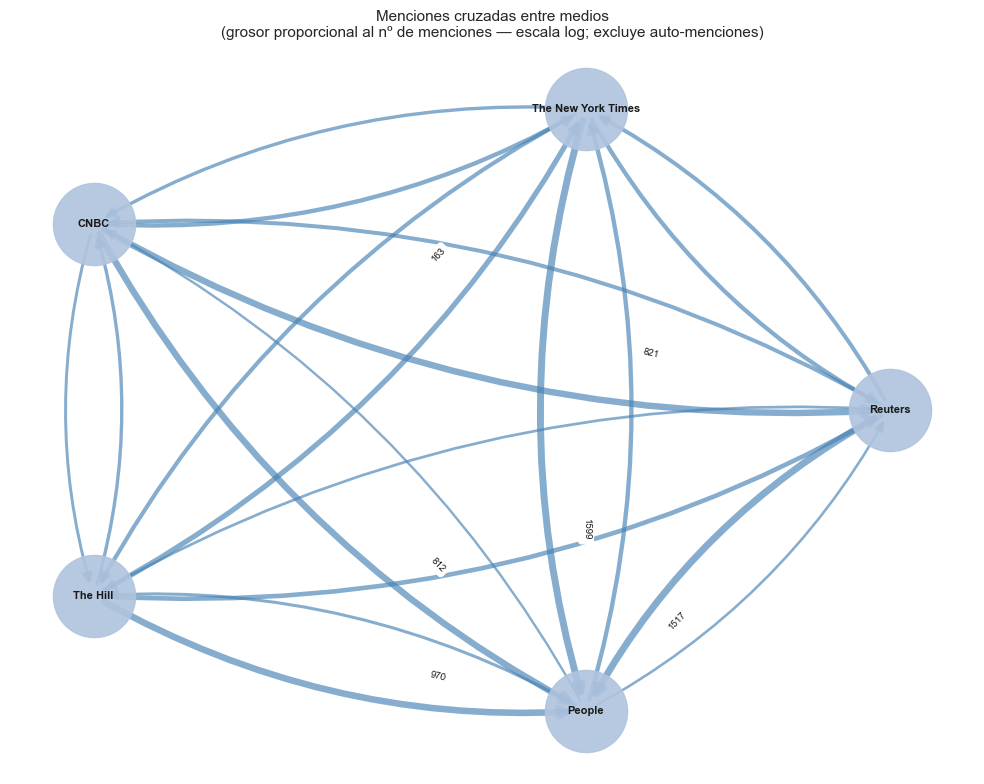

In [254]:
import numpy as np

G = nx.DiGraph()
for m in top_5_publications:
    G.add_node(m)

# Solo menciones cruzadas (excluye auto-menciones de la diagonal)
for i in top_5_publications:
    for j in top_5_publications:
        if i != j:
            w = int(mentions_matrix.loc[i, j])
            if w > 0:
                G.add_edge(i, j, weight=w)

plt.figure(figsize=(10, 8))
pos = nx.circular_layout(G)

weights = [G[u][v]["weight"] for u, v in G.edges()]
max_w   = max(weights) if weights else 1
# Ancho en escala logarítmica para que Reuters no aplaste todo lo demás
edge_widths = [1 + 4 * np.log1p(w) / np.log1p(max_w) for w in weights]

nx.draw_networkx_nodes(G, pos, node_size=3500, node_color="lightsteelblue", alpha=0.9)
nx.draw_networkx_labels(G, pos, font_size=8, font_weight="bold")
nx.draw_networkx_edges(
    G, pos,
    width=edge_widths,
    alpha=0.65,
    edge_color="steelblue",
    arrows=True,
    arrowsize=15,
    connectionstyle="arc3,rad=0.15",
)

# Etiquetar solo las aristas más relevantes para no saturar el gráfico
edge_labels = {(u, v): G[u][v]["weight"]
               for u, v in G.edges() if G[u][v]["weight"] > 100}
nx.draw_networkx_edge_labels(G, pos, edge_labels=edge_labels,
                              font_size=7, label_pos=0.3)

plt.title(
    "Menciones cruzadas entre medios\n"
    "(grosor proporcional al nº de menciones — escala log; excluye auto-menciones)",
    fontsize=11
)
plt.axis("off")
plt.tight_layout()
plt.show()


## D. Preguntas propuestas
Proponga al menos tres preguntas que se podrían intentar responder a partir de estos datos, y mencione posibles caminos para responderlas, sin implementar nada.

A continuación se proponen tres preguntas que podrían responderse con estos datos:

**1. ¿En qué días de la semana publica más cada medio?**
Un groupby sobre date.dt.dayofweek y un heatmap o bar chart. Muy fácil y puede mostrar diferencias interesantes (ej: medios que bajan el fin de semana vs. los que no).

**2. ¿Ha cambiado el foco temático de cada medio a lo largo del tiempo?**
Dividiendo los artículos por año o trimestre y calculando las palabras más frecuentes
por período, se podría visualizar si hay eventos que generaron picos de cobertura
(ej.: elecciones, crisis económicas) y si todos los medios los cubrieron de igual forma.

**3. ¿Qué tan similar es el vocabulario entre medios?**
Construyendo vectores de frecuencia de palabras por medio y calculando la similitud
coseno entre pares, se podría obtener una medida de qué tan parecidos son en estilo
o contenido. Medios con alta similitud serían más difíciles de clasificar automáticamente.